In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df = pd.read_csv("../data/processed_dataset.csv")

## Travail sur un site spécifique

In [85]:
site_name = df['site_name'].unique()[1]
print(site_name)

Mermaid Offshore WP


In [86]:
data = df[df['site_name'] == site_name].copy()
data = data.sort_values('delivery_time')

In [87]:
data['installed_capacity'].unique()

array([235.5])

In [88]:
wind_threshold = 5.0
prod_threshold = 0.05

In [89]:
data['is_maintenance'] = (
        (data['wind_speed_100m'] > wind_threshold) & 
        (data['production'] < data["installed_capacity"]*prod_threshold)
    ).astype(int)

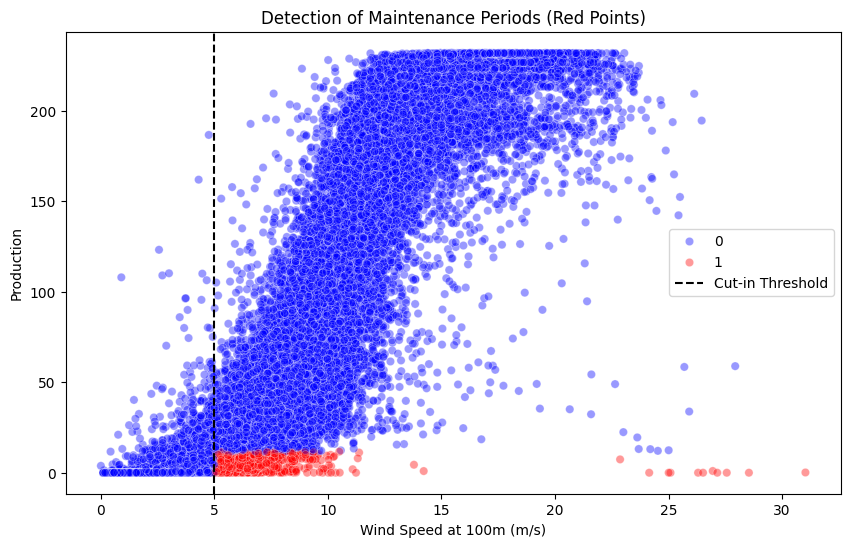

In [90]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data, 
    x='wind_speed_100m', 
    y='production', 
    hue='is_maintenance',
    palette={0: 'blue', 1: 'red'},
    alpha=0.4
)
plt.title('Detection of Maintenance Periods (Red Points)')
plt.xlabel('Wind Speed at 100m (m/s)')
plt.ylabel('Production')
plt.axvline(x=5.0, color='black', linestyle='--', label='Cut-in Threshold')
plt.legend()
plt.show()

In [95]:
def plot_production_time_series_with_maintenance(df, site_name, wind_threshold, prod_threshold):
    data = df[df['site_name'] == site_name].copy()
    
    data['delivery_time'] = pd.to_datetime(data['delivery_time'])
    data = data.sort_values('delivery_time')
    
    # 2. Logique de maintenance
    data['is_maintenance'] = (
        (data['wind_speed_100m'] > wind_threshold) & 
        (data['production'] < data["installed_capacity"]*prod_threshold)
    ).astype(int)

    # 3. Graphique
    plt.figure(figsize=(16, 6))
    
    # Tracer la production
    plt.plot(data['delivery_time'], data['production'], color='dodgerblue', 
             label='Production réelle', alpha=0.7)

    # Tracer les maintenances
    maint_data = data[data['is_maintenance'] == 1]
    plt.scatter(maint_data['delivery_time'], maint_data['production'], 
                color='red', label='Maintenance détectée', s=15, zorder=5)

    # 4. Zoom (C'est ici que ça bloquait)
    # On définit les bornes en s'assurant qu'elles sont compatibles
    start_date = pd.Timestamp('2023-01-01')
    end_date = pd.Timestamp('2023-02-01')
    plt.xlim(start_date, end_date)

    plt.title(f'Série Temporelle de Production : {site_name}')
    plt.ylabel('Production (MW)')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

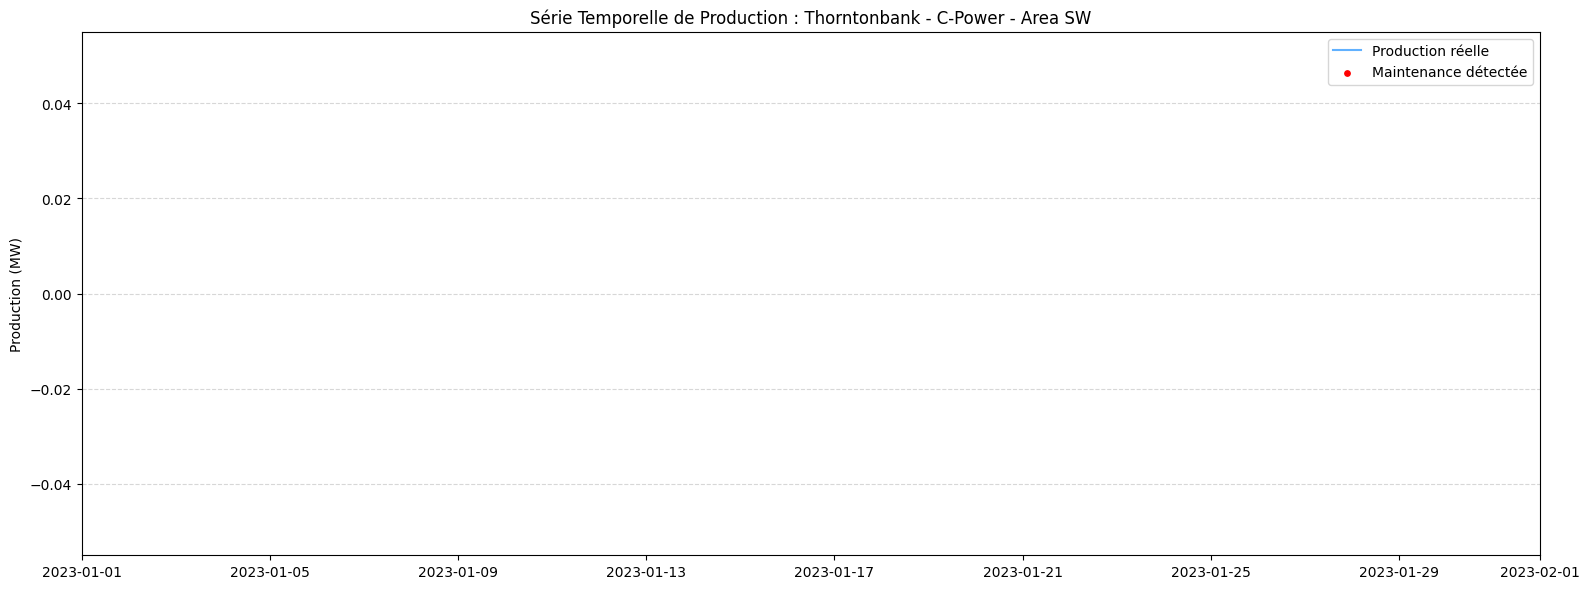

In [96]:
plot_production_time_series_with_maintenance(data, site_name, wind_threshold=wind_threshold, prod_threshold=prod_threshold)

## Visualisation pour tous les sites

In [93]:
df["site_name"].unique()

array(['Belwind Phase 1', 'Mermaid Offshore WP',
       'Nobelwind Offshore Windpark', 'Norther Offshore WP',
       'Northwester 2', 'Northwind', 'Rentel Offshore WP',
       'Seastar Offshore WP', 'Thorntonbank - C-Power - Area NE',
       'Thorntonbank - C-Power - Area SW'], dtype=object)

Belwind Phase 1


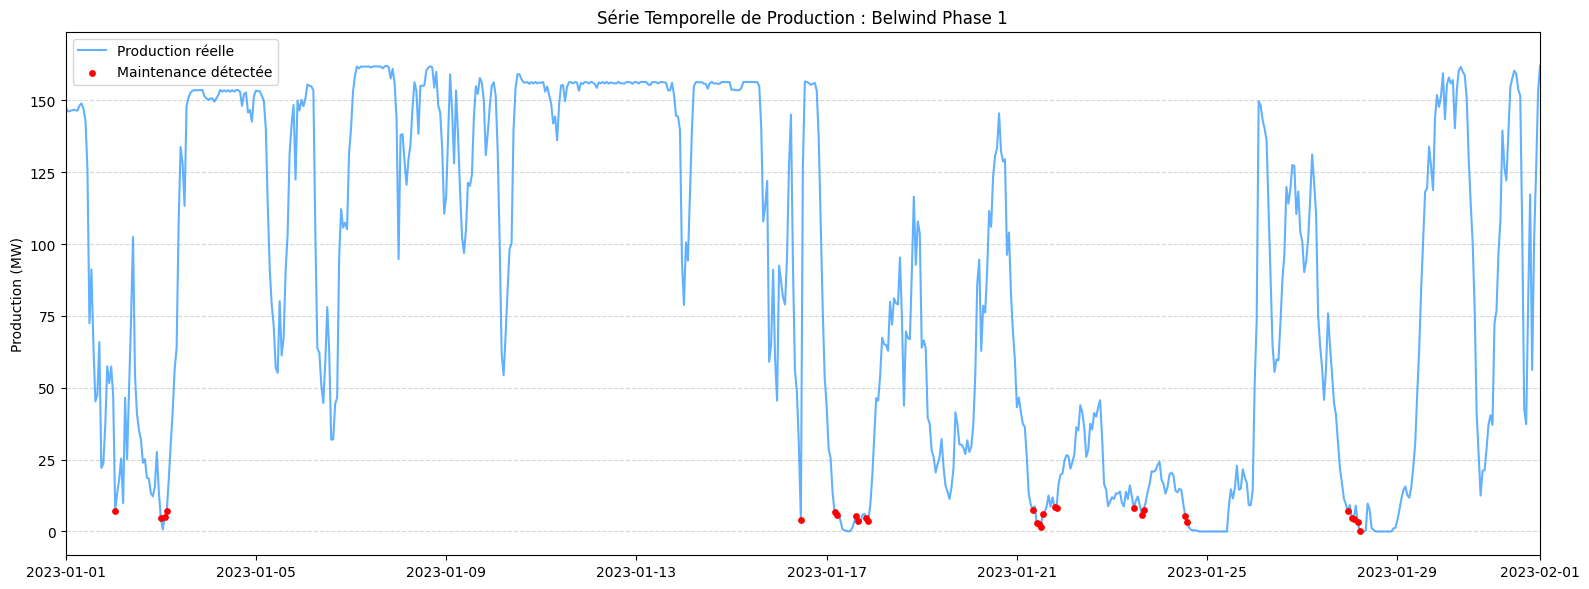

Mermaid Offshore WP


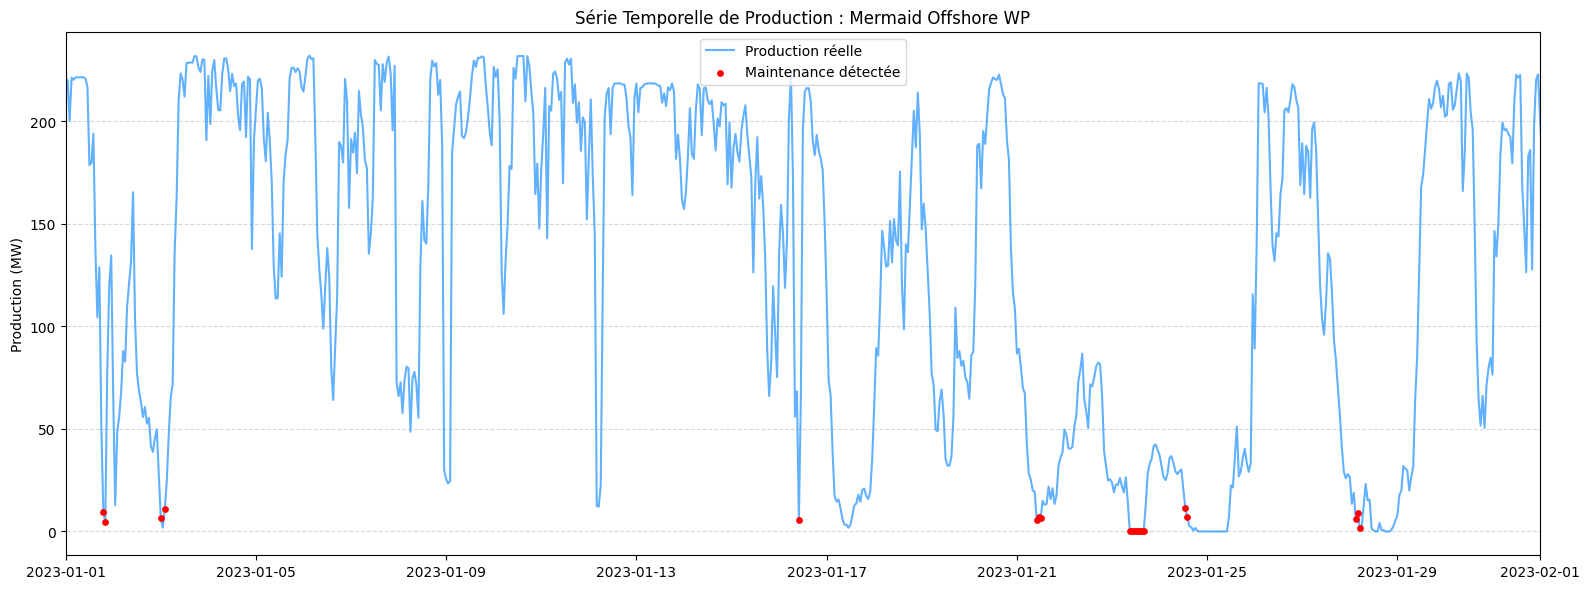

Nobelwind Offshore Windpark


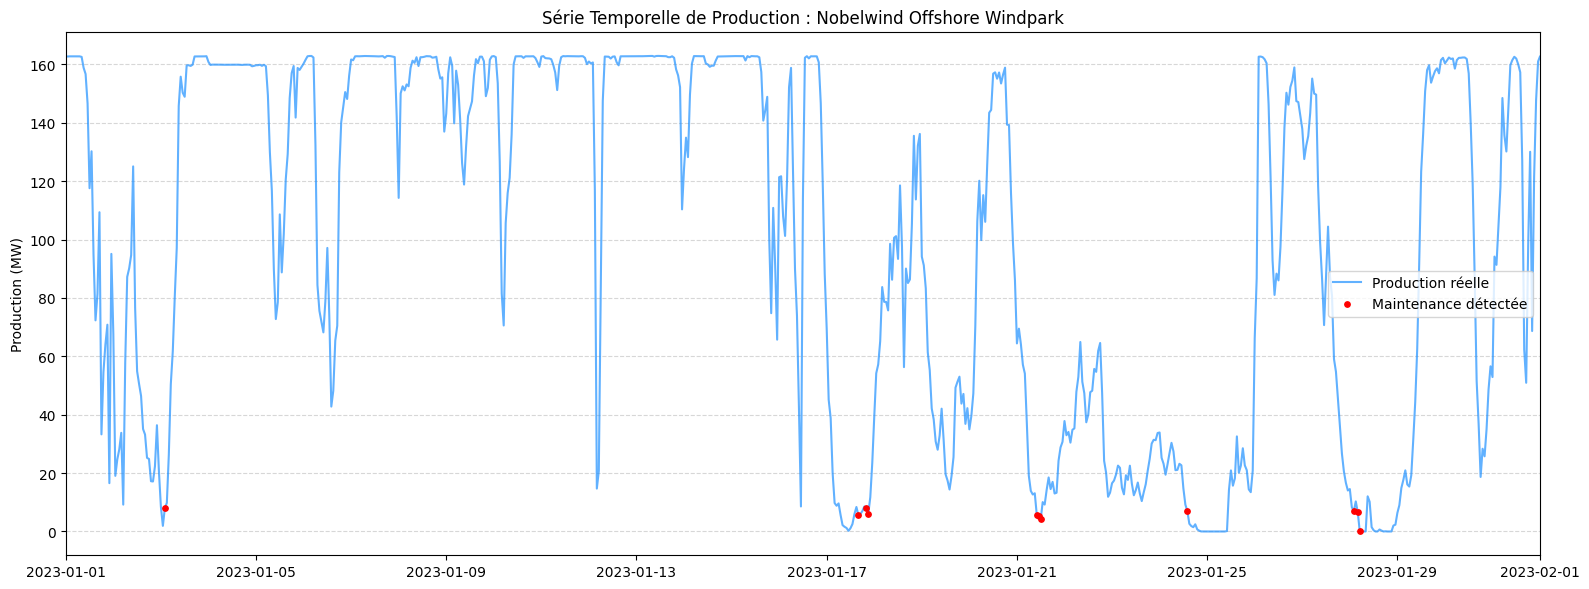

Norther Offshore WP


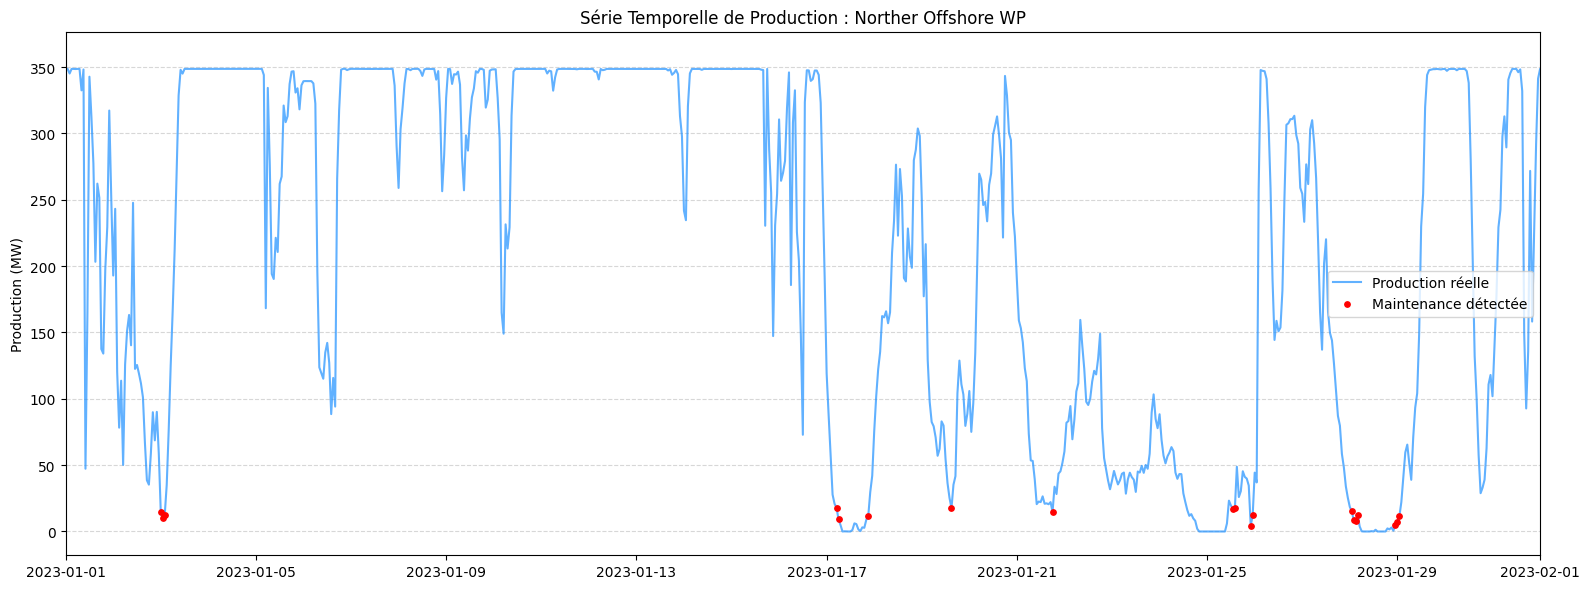

Northwester 2


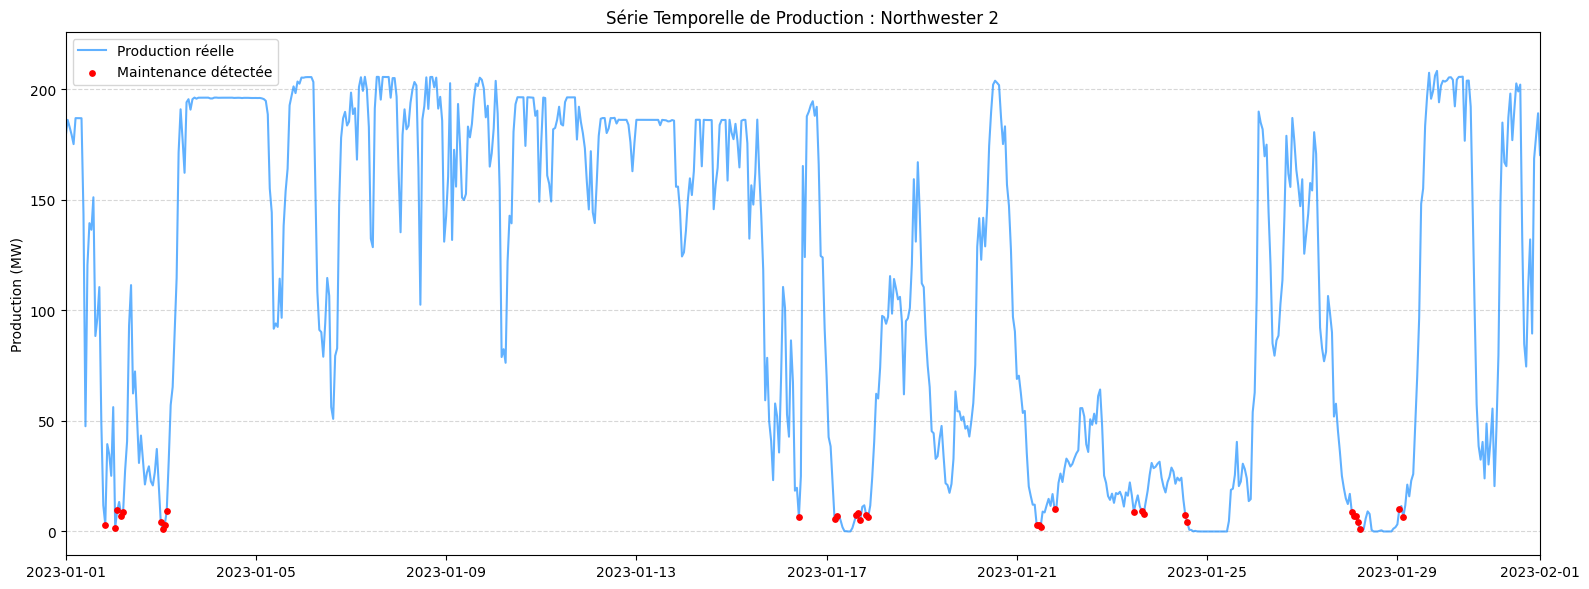

Northwind


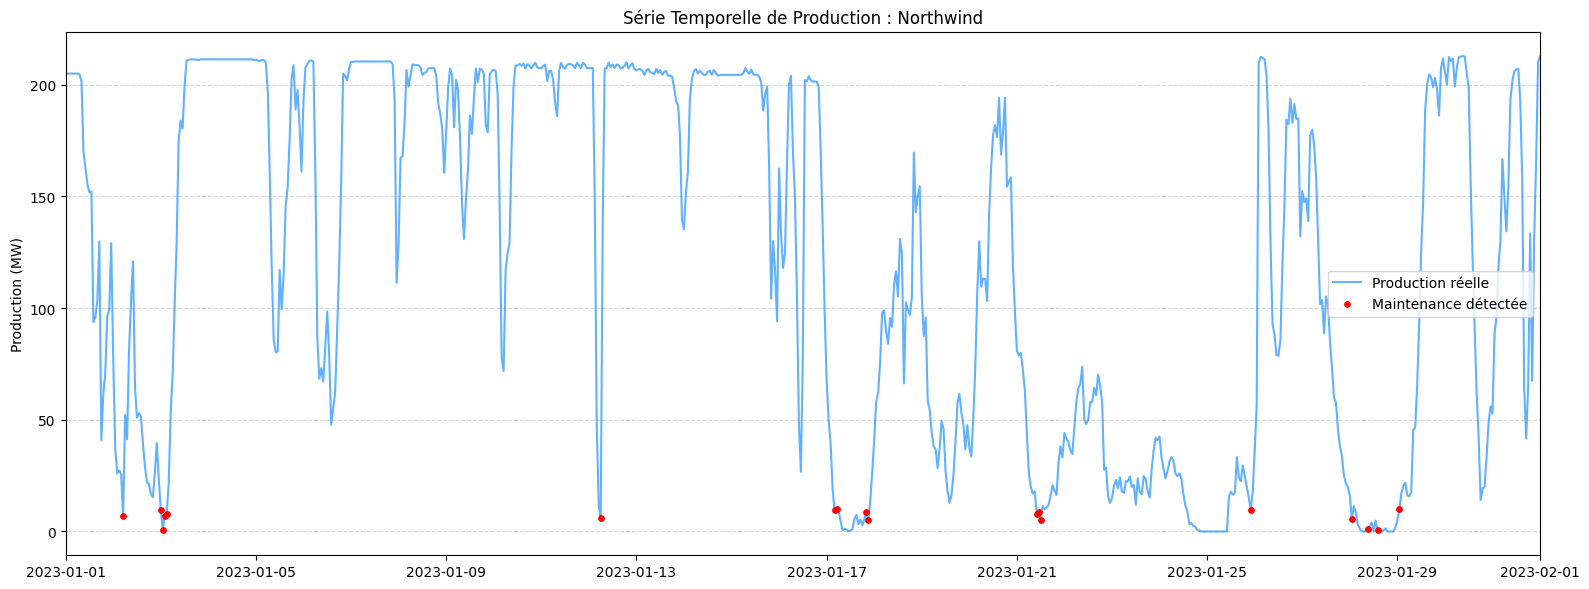

Rentel Offshore WP


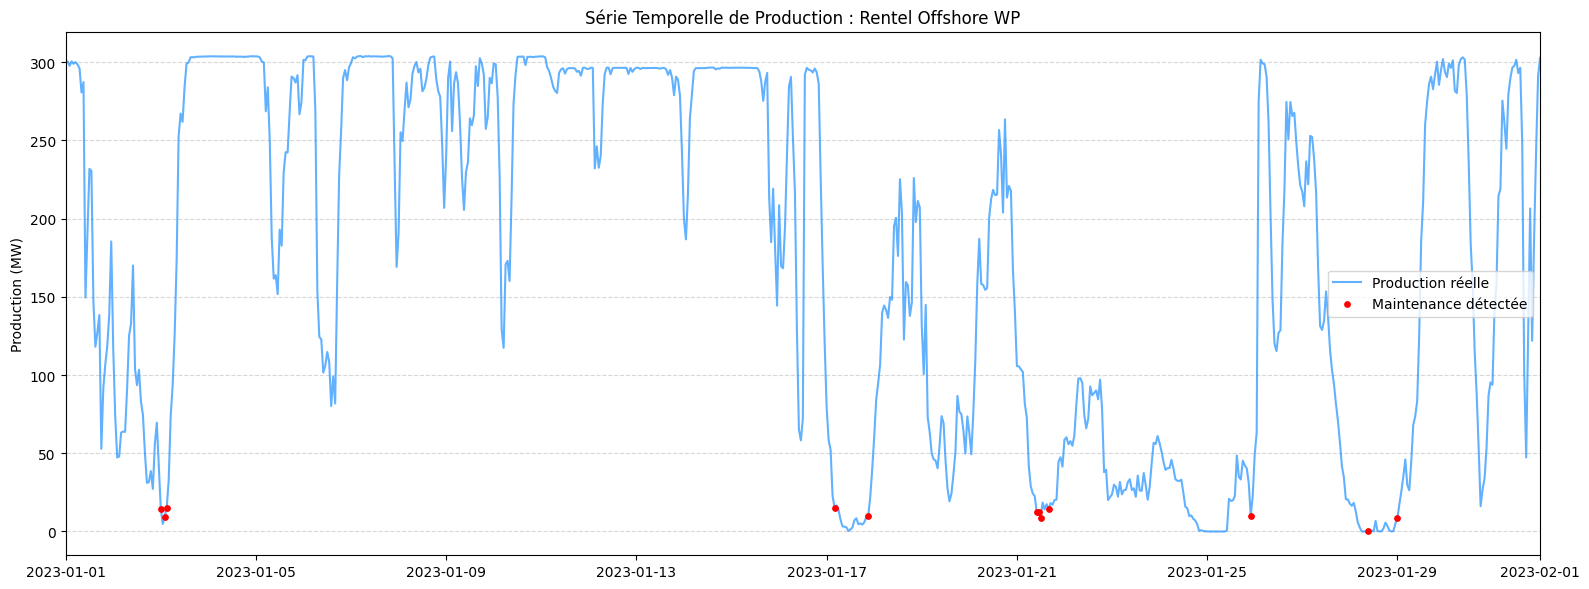

Seastar Offshore WP


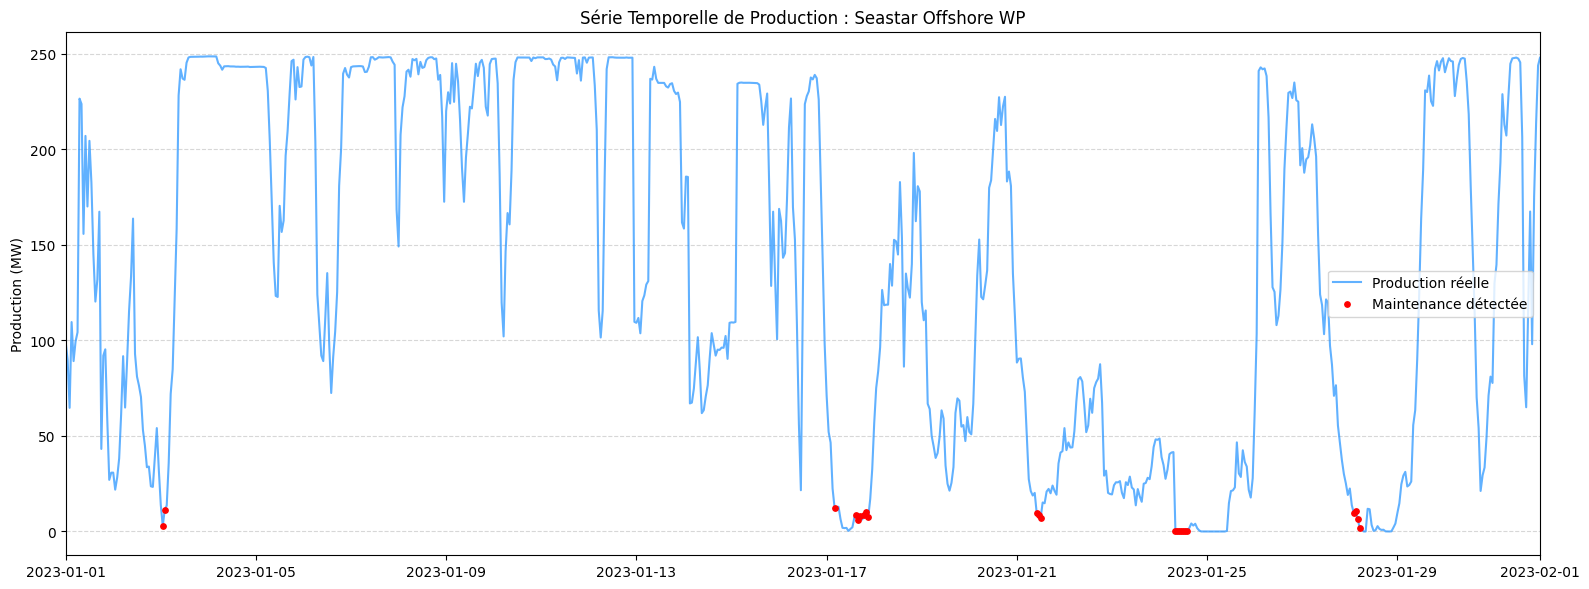

Thorntonbank - C-Power - Area NE


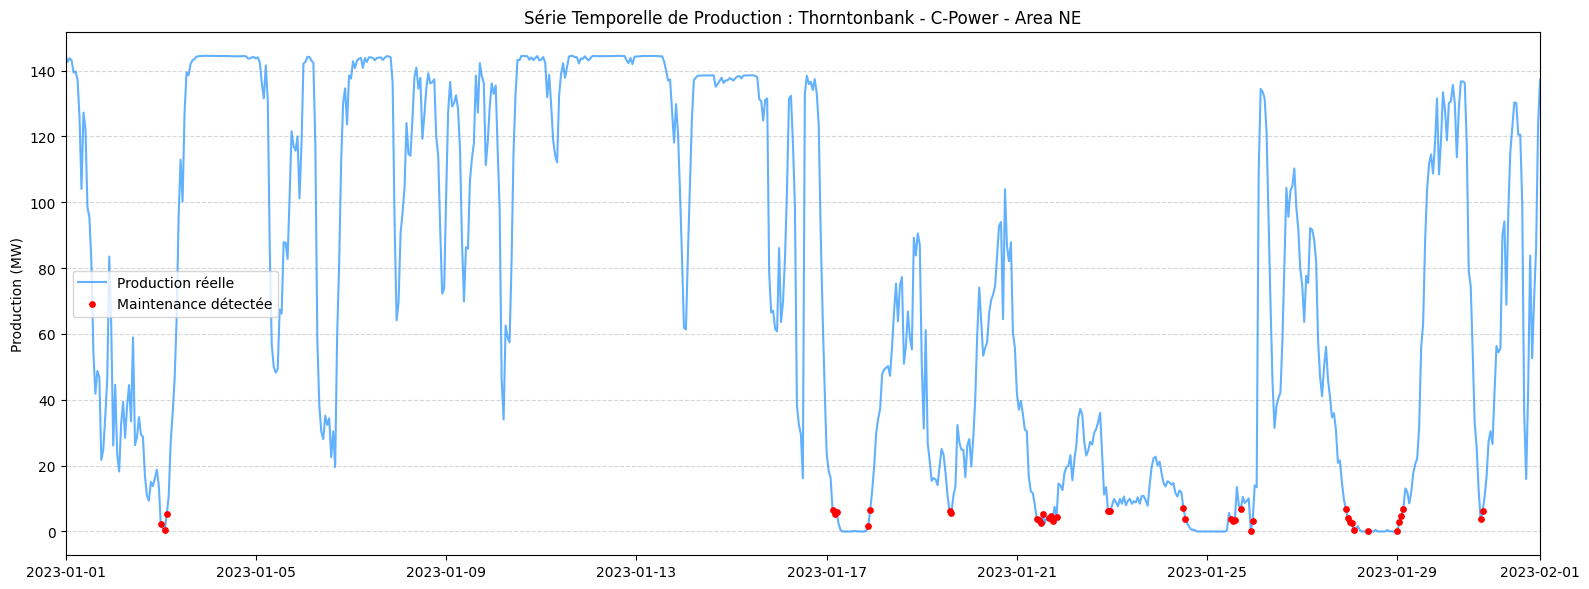

Thorntonbank - C-Power - Area SW


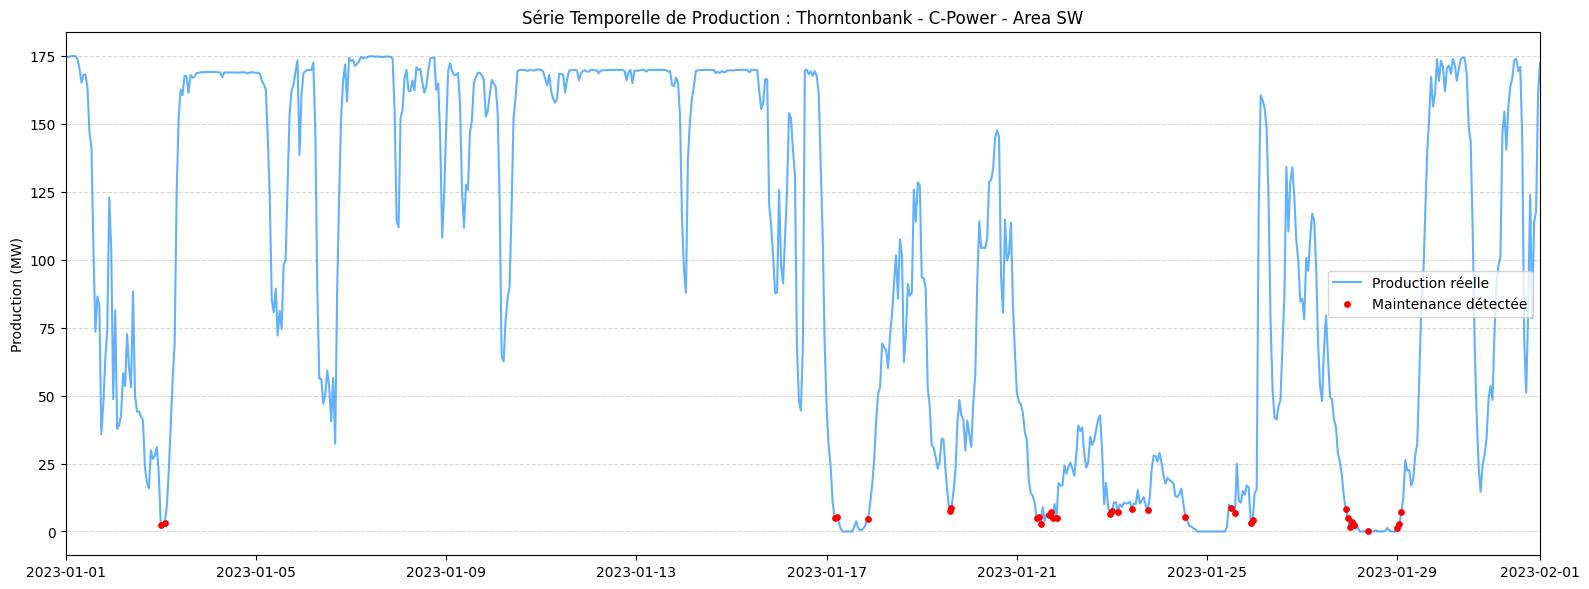

In [94]:
for site_name in df["site_name"].unique():
    print(site_name)
    plot_production_time_series_with_maintenance(df, site_name)

In [98]:
def apply_maintenance_logic(df, site_name, wind_limit=5.0, cap_limit=0.05):
    """
    Identifie les maintenances en utilisant la capacité installée.
    
    Args:
        df: DataFrame fusionné
        wind_limit: Vitesse du vent min pour attendre une production (m/s)
        cap_limit: Ratio min de la capacité installée (0.05 = 5%)
    """
    data = df[df['site_name'] == site_name].copy()
    data['is_maintenance'] = (
        (data['wind_speed_100m'] > wind_limit) & 
        (data['production'] < (data['installed_capacity'] * cap_limit))
    ).astype(int)
    
    nb_maint = data['is_maintenance'].sum()
    print(f"Détection terminée : {nb_maint} heures de maintenance identifiées.")
    
    return data

In [99]:
for site_name in df.site_name.unique():
    print(site_name)
    apply_maintenance_logic(df, site_name, wind_limit=wind_threshold, cap_limit=prod_threshold)

Belwind Phase 1
Détection terminée : 3283 heures de maintenance identifiées.
Mermaid Offshore WP
Détection terminée : 1754 heures de maintenance identifiées.
Nobelwind Offshore Windpark
Détection terminée : 2260 heures de maintenance identifiées.
Norther Offshore WP
Détection terminée : 2075 heures de maintenance identifiées.
Northwester 2
Détection terminée : 3169 heures de maintenance identifiées.
Northwind
Détection terminée : 2956 heures de maintenance identifiées.
Rentel Offshore WP
Détection terminée : 2373 heures de maintenance identifiées.
Seastar Offshore WP
Détection terminée : 2447 heures de maintenance identifiées.
Thorntonbank - C-Power - Area NE
Détection terminée : 3905 heures de maintenance identifiées.
Thorntonbank - C-Power - Area SW
Détection terminée : 3207 heures de maintenance identifiées.
